# 10 · Explicabilidad con SHAP (modelo v4)

Valores SHAP del LightGBM v4 (el desplegado) sobre una muestra de diciembre de 2023. SHAP reparte la predicción de cada cliente entre sus variables: cuánto empuja cada una la probabilidad hacia arriba o hacia abajo respecto al promedio. Se usa el cálculo nativo de LightGBM (TreeSHAP), el mismo que expone la API en `/explain`, así las explicaciones siempre corresponden al modelo cargado.

1. Modelo y muestra · 2. Importancia global · 3. Dependencias · 4. Explicaciones individuales · 5. SHAP frente a permutación · 6. Registro en MLflow

In [1]:
import warnings, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import shap

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from inferencia import Modelo
from tracking import grupo, registrar_final
C_BLUE, C_ORANGE, C_GRAY, C_MUTED = "#2a78d6", "#eb6834", "#c9c8c3", "#52514e"
mpl.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": C_GRAY, "axes.grid": True, "grid.color": "#ececea",
                     "axes.axisbelow": True, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.labelcolor": C_MUTED, "xtick.color": C_MUTED, "ytick.color": C_MUTED})

## 1. Modelo y muestra

Paquete `models/v4` y 20.000 filas de diciembre de 2023 (el mes de validación). Los valores SHAP están en escala logit; la probabilidad es la sigmoide del valor base más la suma de contribuciones.

In [2]:
modelo = Modelo.cargar(ROOT / "models" / "v4")
train = pd.read_parquet(ROOT / "data" / "processed" / "train_fe.parquet")
dic = train[train.fecha_var_rpta_alt == 202312].sample(20000, random_state=42).reset_index(drop=True)
X = dic[modelo.features]; y = dic.var_rpta_alt.to_numpy()
C, base = modelo.contribuciones(X)
p = 1 / (1 + np.exp(-(base + C.sum(axis=1))))
# Para los gráficos, las categóricas se representan por su código (SHAP colorea por valor numérico)
X_plot = X.copy()
for c in modelo.categoricas: X_plot[c] = X_plot[c].cat.codes.replace(-1, np.nan)
exp = shap.Explanation(values=C, base_values=base, data=X_plot.to_numpy(), feature_names=modelo.features)
print(f"muestra {len(X):,} filas | valor base medio {base.mean():.3f} (prob {1/(1+np.exp(-base.mean())):.3f}) | prob media {p.mean():.3f} | tasa real {y.mean():.3f}")

muestra 20,000 filas | valor base medio -0.097 (prob 0.476) | prob media 0.468 | tasa real 0.465


## 2. Importancia global

Izquierda: media del valor absoluto de SHAP por variable (cuánto mueve la predicción en promedio). Derecha: distribución de los valores SHAP por cliente, coloreada por el valor de la variable (rojo alto, azul bajo), para ver el sentido del efecto.

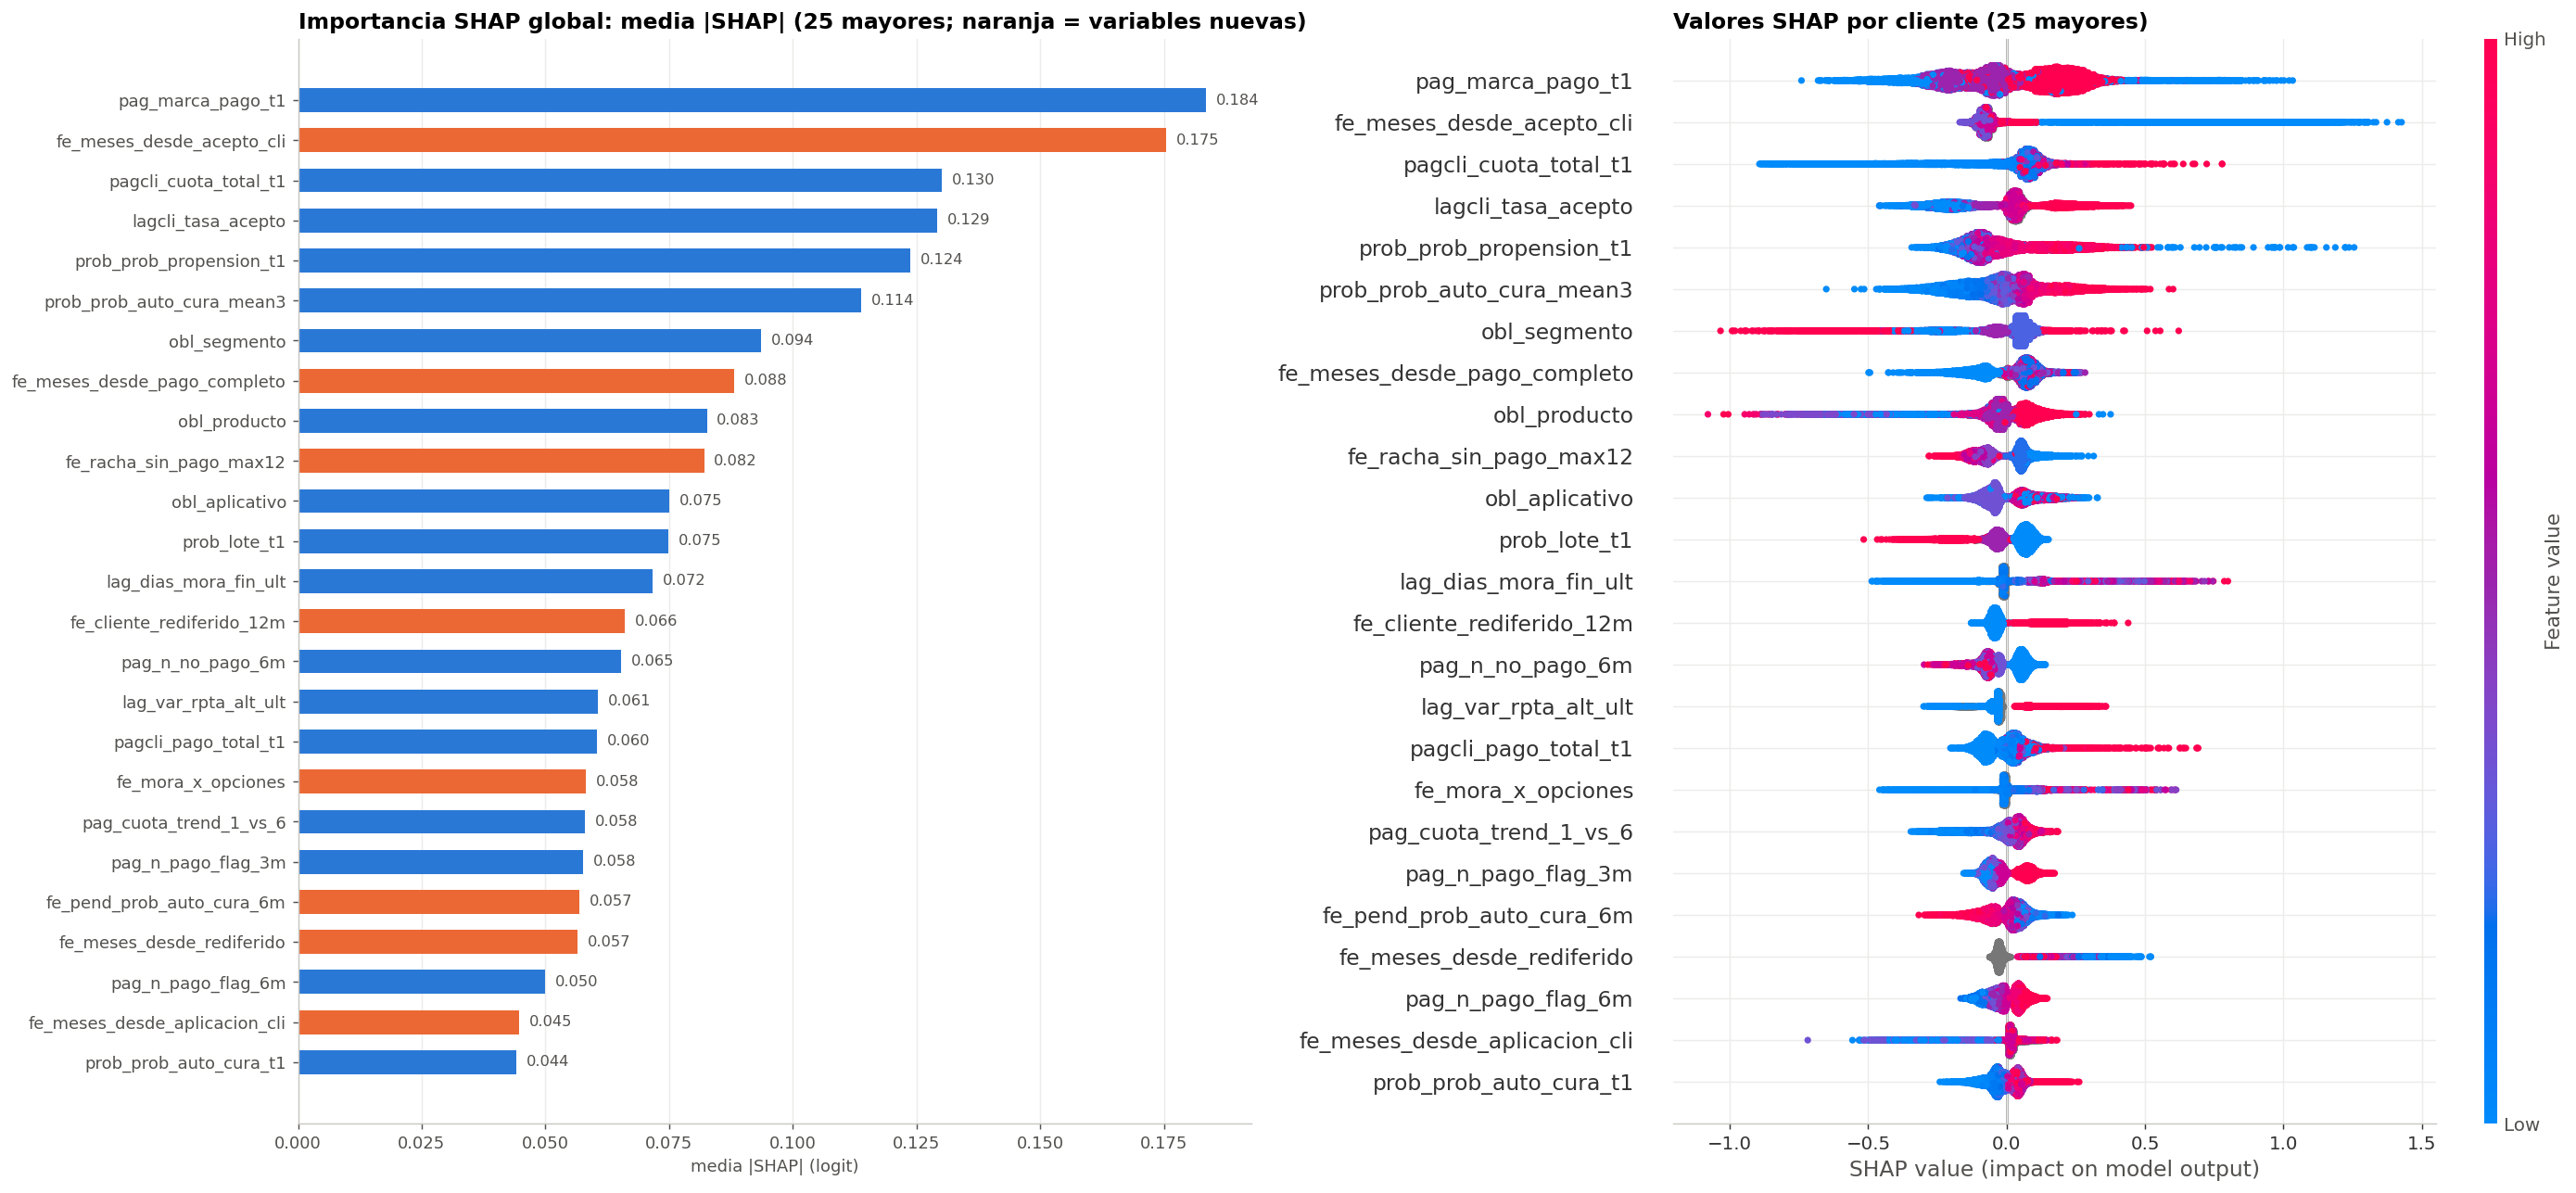

Importancia acumulada de las 10 primeras: 36.2% | de las 25 primeras: 63.4%


In [3]:
imp = pd.Series(np.abs(C).mean(axis=0), index=modelo.features).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
d = imp.head(25).iloc[::-1]
axes[0].barh(d.index, d.values, color=[C_ORANGE if f.startswith("fe_") else C_BLUE for f in d.index], height=0.6)
for yv, v in zip(d.index, d.values): axes[0].text(v + 0.002, yv, f"{v:.3f}", va="center", fontsize=9, color=C_MUTED)
axes[0].set_title("Importancia SHAP global: media |SHAP| (25 mayores; naranja = variables nuevas)"); axes[0].grid(axis="y", visible=False); axes[0].set_xlabel("media |SHAP| (logit)")
plt.sca(axes[1]); shap.summary_plot(C, X_plot, feature_names=modelo.features, max_display=25, show=False, plot_size=None); axes[1].set_title("Valores SHAP por cliente (25 mayores)")
plt.tight_layout(); fig_global = fig; plt.show()
print("Importancia acumulada de las 10 primeras:", f"{imp.head(10).sum() / imp.sum():.1%}", "| de las 25 primeras:", f"{imp.head(25).sum() / imp.sum():.1%}")

**Lectura.** Las variables con mayor peso son las de comportamiento reciente y las de historial de aceptación del cliente; los scores del banco aparecen entre las primeras. El gráfico de la derecha muestra el sentido: para cada variable, si los valores altos (rojo) empujan hacia aceptar (derecha) o hacia no aceptar (izquierda). Ese sentido es lo que el agente puede convertir en una frase para el gestor.

## 3. Dependencias

Para las cuatro variables más importantes, el valor SHAP en función del valor de la variable. Muestra la forma del efecto (lineal, con umbral, saturado) y dónde cambia de signo.

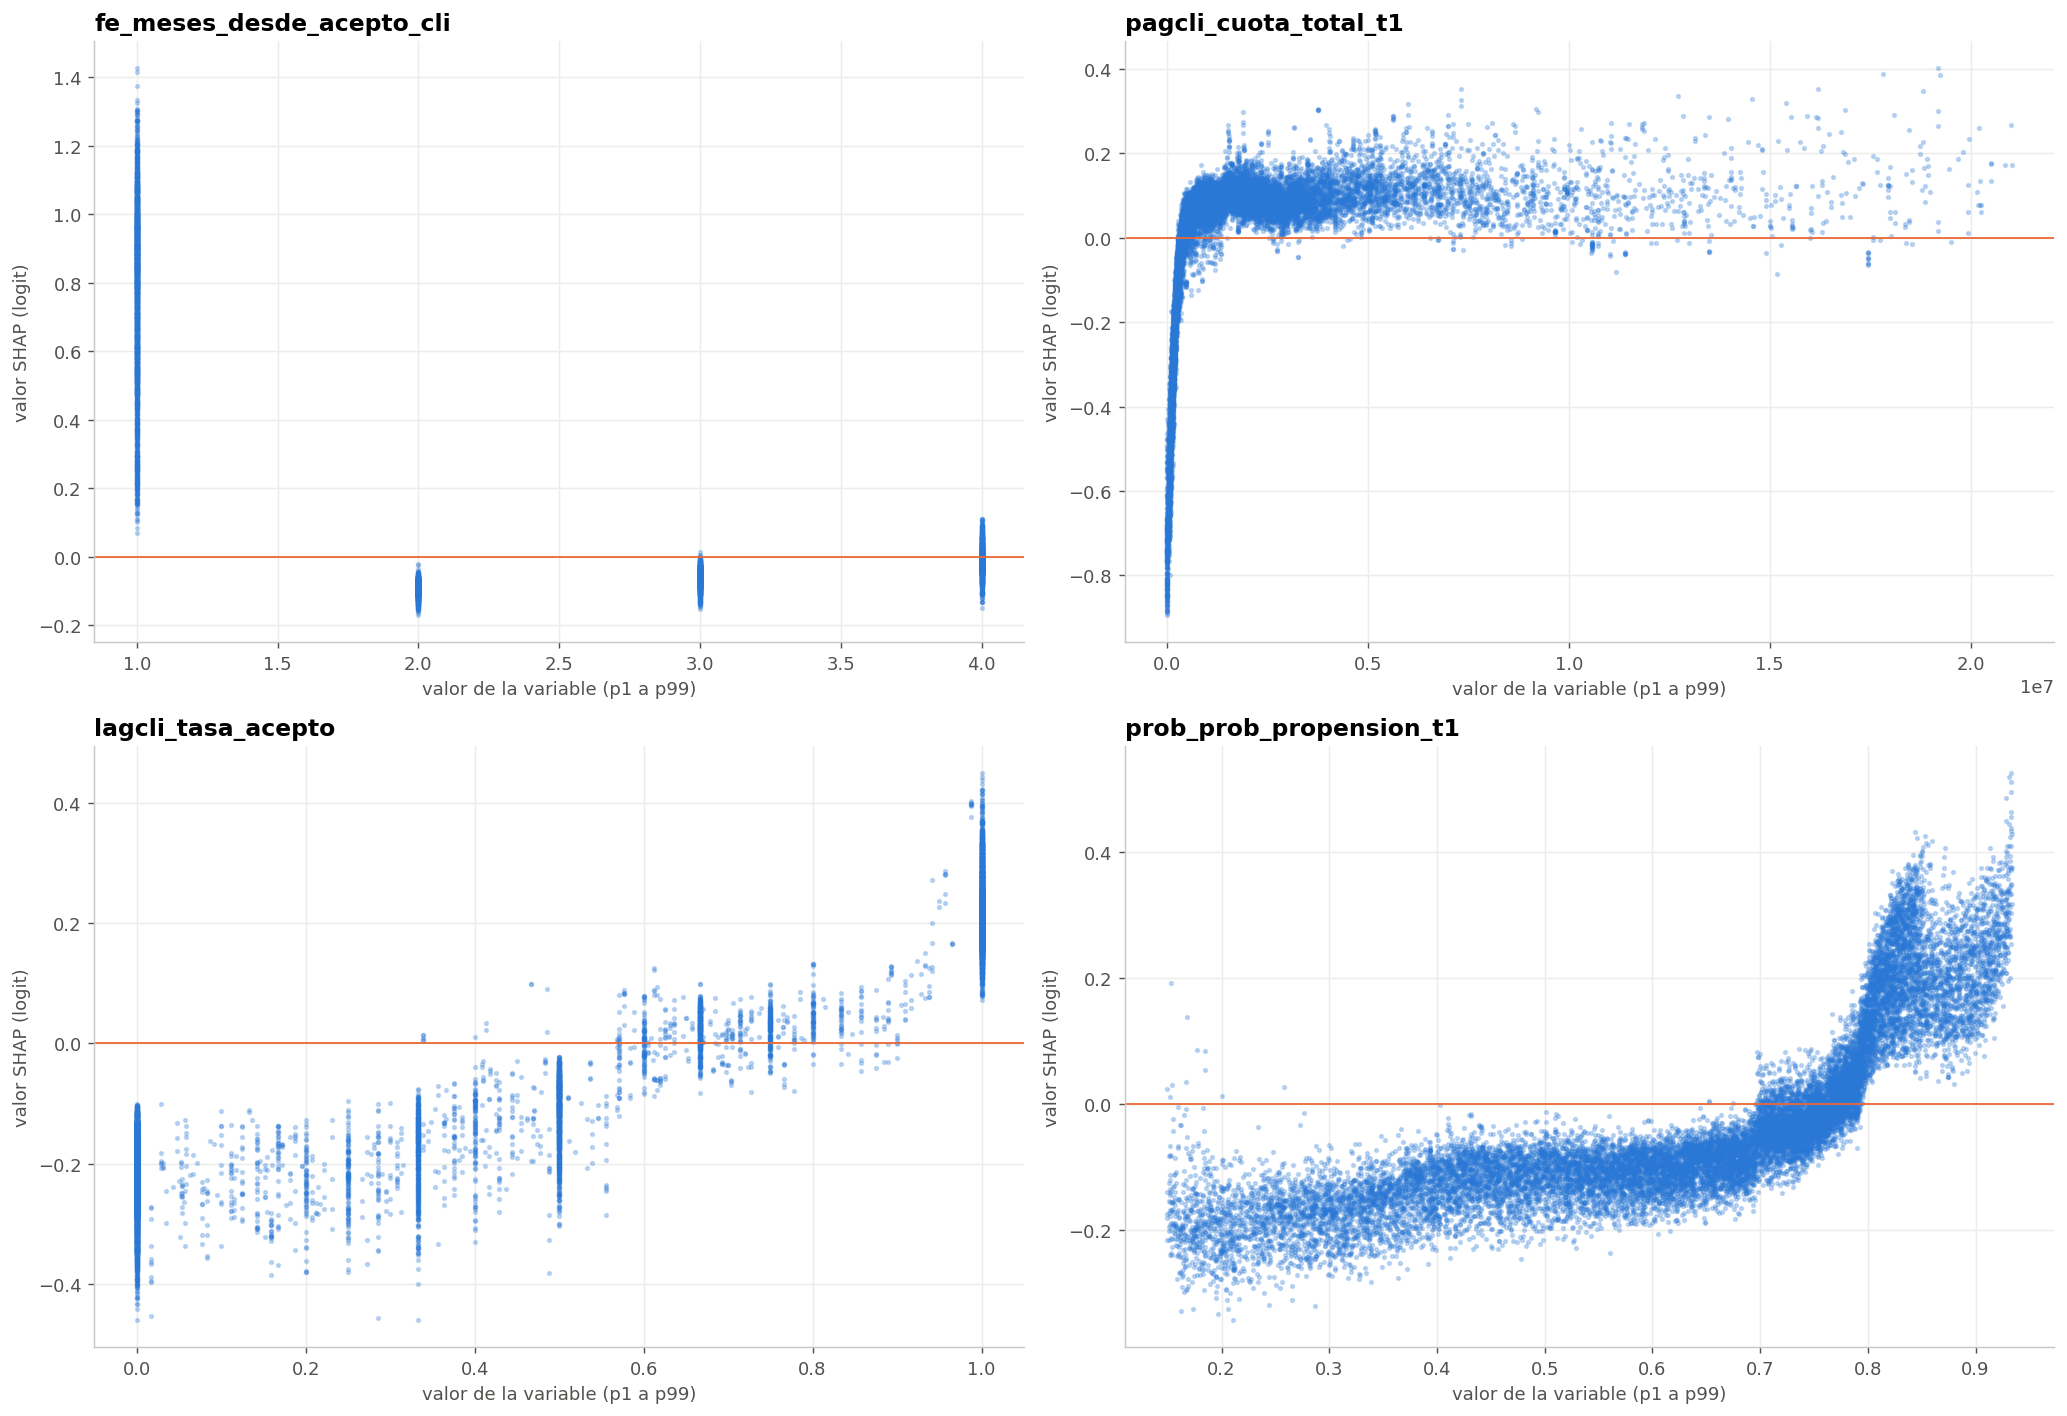

In [4]:
top4 = [f for f in imp.index if f not in modelo.categoricas][:4]
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for ax, f in zip(axes.ravel(), top4):
    j = modelo.features.index(f); x = X_plot[f].to_numpy(); s = C[:, j]; m = ~np.isnan(x)
    lo, hi = np.nanpercentile(x, [1, 99]); m &= (x >= lo) & (x <= hi)
    ax.scatter(x[m], s[m], s=4, alpha=0.25, color=C_BLUE); ax.axhline(0, color=C_ORANGE, lw=1)
    ax.set_title(f"{f}"); ax.set_xlabel("valor de la variable (p1 a p99)"); ax.set_ylabel("valor SHAP (logit)")
plt.tight_layout(); fig_dep = fig; plt.show()

**Lectura.** La línea naranja es el efecto nulo; los puntos por encima empujan hacia aceptar. Las curvas dicen, por ejemplo, a partir de qué número de meses desde la última aceptación el efecto se vuelve negativo, o cómo crece el efecto con la propensión de pago del banco. Son las reglas que el modelo aprendió, expresadas de forma que se pueden contrastar con la intuición del negocio.

## 4. Explicaciones individuales

Tres clientes de diciembre: uno con probabilidad alta, uno cerca del umbral (0,33) y uno con probabilidad baja. Cada gráfico muestra cómo se llega desde el valor base hasta la predicción, variable por variable. Es exactamente lo que devuelve `/explain` en la API.

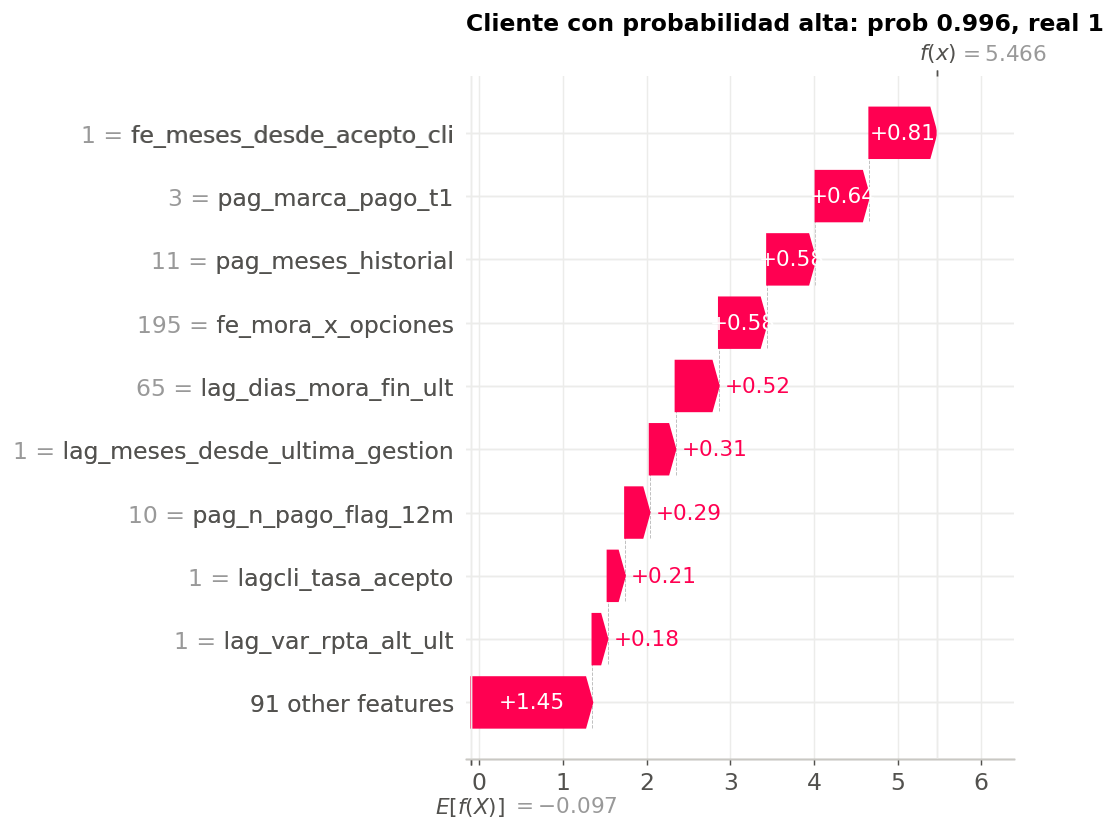

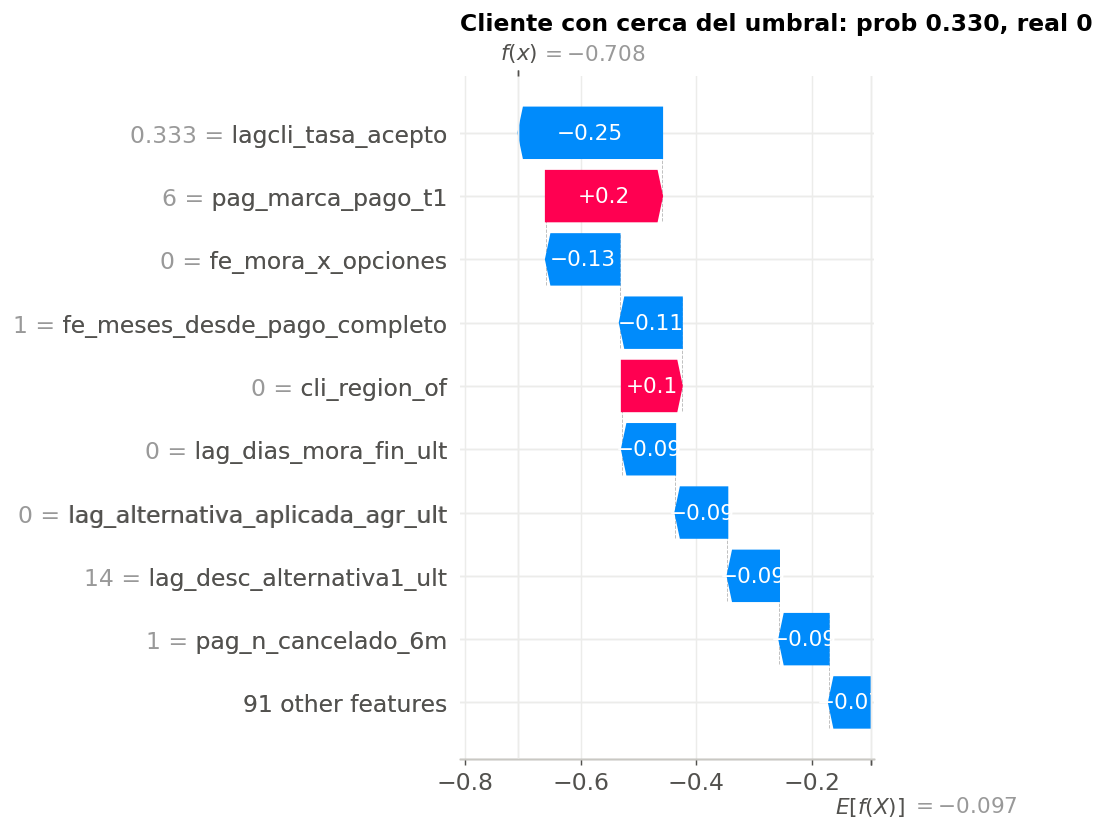

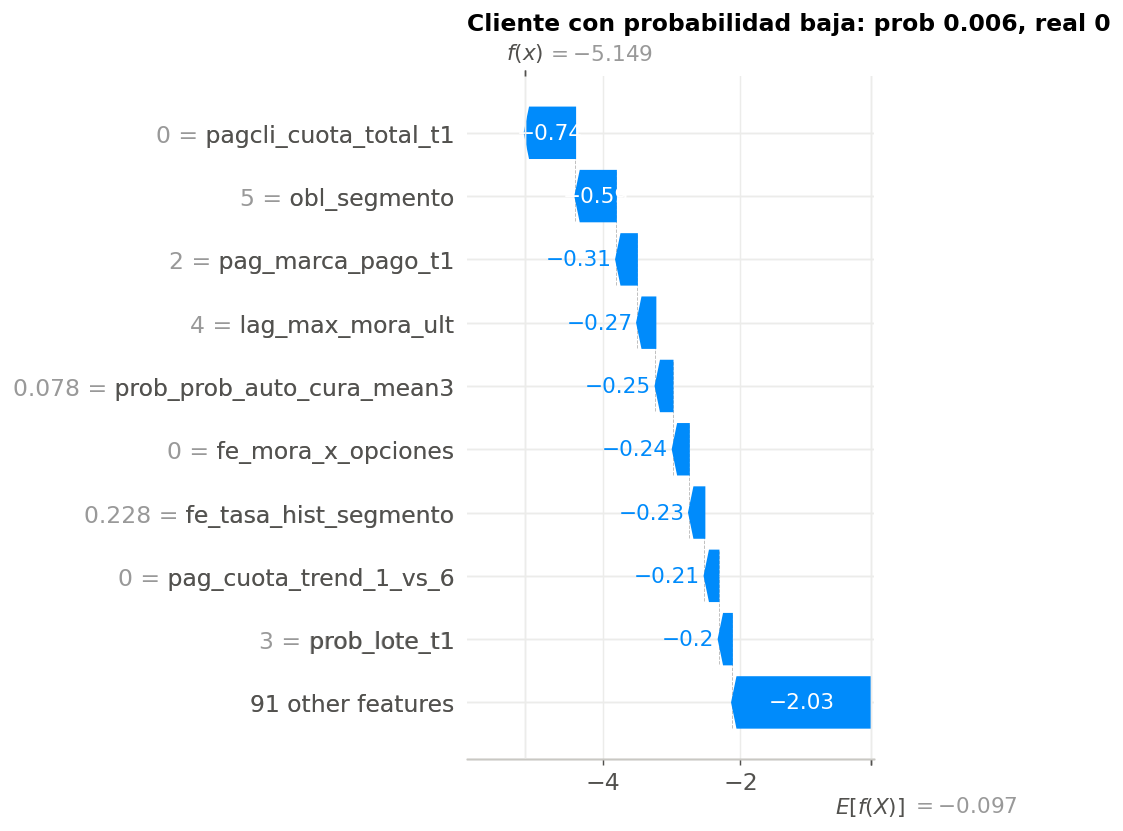

Salida de la API (/explain) para el cliente cerca del umbral:
   baja  -0.249  lagcli_tasa_acepto = 0.3333333333333333
   sube  +0.202  pag_marca_pago_t1 = PAGO_MENOS
   baja  -0.128  fe_mora_x_opciones = 0.0
   baja  -0.108  fe_meses_desde_pago_completo = 1.0
   sube  +0.104  cli_region_of = ANTIOQUIA


In [5]:
i_alta = int(np.argmax(p)); i_baja = int(np.argmin(p)); i_umb = int(np.argmin(np.abs(p - modelo.umbral)))
figs_local = {}
for i, t in [(i_alta, "probabilidad alta"), (i_umb, "cerca del umbral"), (i_baja, "probabilidad baja")]:
    plt.figure(figsize=(11, 6)); shap.plots.waterfall(exp[i], max_display=10, show=False)
    plt.title(f"Cliente con {t}: prob {p[i]:.3f}, real {int(y[i])}", loc="left", fontweight="bold"); plt.tight_layout()
    figs_local[t.replace(" ", "_")] = plt.gcf(); plt.show()
print("Salida de la API (/explain) para el cliente cerca del umbral:")
for f in modelo.explicar(X.iloc[[i_umb]], k=5)[0]["factores"]: print(f"   {f['sentido']:<5} {f['contribucion']:+.3f}  {f['variable']} = {f['valor']}")

**Lectura.** Para un cliente concreto, las barras rojas son las variables que suben su probabilidad y las azules las que la bajan, en orden de magnitud. La suma reconstruye exactamente la predicción del modelo. Esta es la explicación que el agente entrega al gestor: no "el modelo dice 0,64" sino "0,64 porque pagó el mes pasado, tiene alta propensión según el banco y su cliente aceptó hace dos meses; en contra, lleva cuatro meses sin un pago completo".

## 5. SHAP frente a permutación

Comparación con la importancia por permutación del notebook 08 (caída de F1 en diciembre al barajar la variable). Las dos medidas responden preguntas distintas: SHAP, cuánto mueve la predicción; permutación, cuánto cuesta al F1 quitarla.

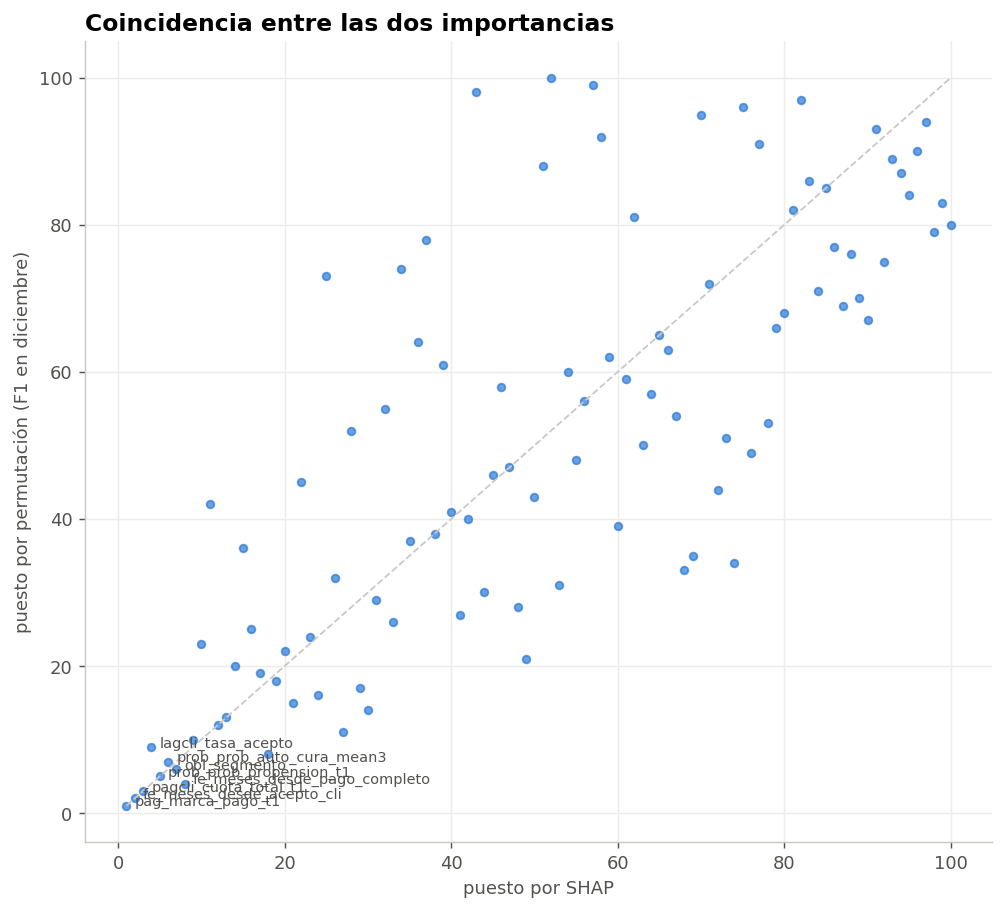

Variables comunes en el top 20 de ambas medidas: 15 | correlación de Spearman entre los puestos: 0.78


In [6]:
perm = pd.read_csv(ROOT / "outputs" / "importancia_08.csv", index_col=0)["caida_F1_permutacion"]
cmp = pd.DataFrame({"rank_shap": imp.rank(ascending=False).astype(int), "rank_permutacion": perm.reindex(imp.index).rank(ascending=False).astype(int)}).sort_values("rank_shap")
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(cmp.rank_shap, cmp.rank_permutacion, s=18, color=C_BLUE, alpha=0.7); ax.plot([1, 100], [1, 100], color=C_GRAY, lw=1, ls="--")
for f, r in cmp.head(8).iterrows(): ax.text(r.rank_shap + 1, r.rank_permutacion, f, fontsize=8, color=C_MUTED)
ax.set_xlabel("puesto por SHAP"); ax.set_ylabel("puesto por permutación (F1 en diciembre)"); ax.set_title("Coincidencia entre las dos importancias"); fig_cmp = fig; plt.show()
coinc = len(set(imp.head(20).index) & set(perm.sort_values(ascending=False).head(20).index))
print(f"Variables comunes en el top 20 de ambas medidas: {coinc} | correlación de Spearman entre los puestos: {cmp.corr(method='spearman').iloc[0, 1]:.2f}")

## 6. Registro en MLflow

Grupo `10_shap_v4` con la importancia global como métrica por variable (25 mayores), las figuras y la tabla completa.

In [7]:
imp.rename("shap_media_abs").to_csv(ROOT / "outputs" / "importancia_shap_v4.csv")
with grupo("10_shap_v4", modelo="lightgbm_v4", notebook="10_shap", validacion="muestra_dic2023_20k", particion="explicabilidad"):
    rid = registrar_final({"modelo": "v4", "muestra": 20000, "mes": 202312, "metodo": "TreeSHAP nativo LightGBM"},
                          {**{f"shap_{f}": float(v) for f, v in imp.head(25).items()}, "shap_top10_pct": float(imp.head(10).sum() / imp.sum()), "coincidencia_top20_permutacion": coinc},
                          modelo.umbral, modelo.features, figuras={"importancia_global": fig_global, "dependencias": fig_dep, "shap_vs_permutacion": fig_cmp, **{f"cliente_{k}": v for k, v in figs_local.items()}}, tags={"tipo_run": "explicabilidad"})
print("run:", rid)

run: cf562d8a363849aebd47f0780cf5f603
